In [1]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
import numpy as np
from variable_leverage_env_1 import agentDLVEnvV2
import torch.optim as optim
from tqdm import trange

import pandas as pd
from utils import plot_episode_history_v2, plot_metrics_v2, plot_economic_metrics, plot


In [2]:
class DummyReLUFeatureExtractor(nn.Module):
    def __init__(self, input_dim, features_dim=64):
        super().__init__()
        self.pre_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, features_dim),
            nn.ReLU()
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        if obs.ndim == 1:
            obs = obs.unsqueeze(0)
        obs = obs.to(dtype=torch.float32)
        return self.pre_layer(obs)

In [3]:
class reccurentActor(nn.Module):
    def __init__(self, 
            obs_dim: int = 10, 
            action_dim: int = 4
        ):
        super().__init__()

        self.obs_dim = obs_dim
        self.action_dim = action_dim

        self.features_extractor = DummyReLUFeatureExtractor(obs_dim, 128)

        self.lstm_actor = nn.LSTM(
            input_size=128,
            hidden_size=256,
            num_layers=1,
            batch_first=True
        )

        self.policy_net = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.action_net = nn.Linear(128, action_dim)

    def init_hidden(self, batch_size=1, device="cpu"):
        """Initial hidden (h,c) for LSTM"""
        h = torch.zeros(1, batch_size, 256).to(device)
        c = torch.zeros(1, batch_size, 256).to(device)

        self.to(device)
        
        return (h, c)
    
    def forward(self, obs, hidden):
        if obs.ndim == 2:   
            obs = obs.unsqueeze(1)  
        elif obs.ndim == 1: 
            obs = obs.unsqueeze(0).unsqueeze(1) 

        batch, seq_len, _ = obs.shape
        feats = self.features_extractor(obs.view(-1, self.obs_dim))
        feats = feats.view(batch, seq_len, -1)

        lstm_out, new_hidden = self.lstm_actor(feats, hidden)

        x = self.policy_net(lstm_out)
        logits = self.action_net(x)  
        return logits, new_hidden
    
    def act(self, obs, hidden, device = "cpu"):
        if isinstance(obs, np.ndarray):
            obs = torch.as_tensor(obs, dtype=torch.float32, device=device)

        logits, new_hidden = self.forward(obs, hidden)
        logits = logits[:, -1, :]
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob, new_hidden
    
    def set_initial_state(self, file_path, device = "cpu"):
        state = torch.load(file_path, map_location = device)

        self.features_extractor.load_state_dict(state["features_extractor"])
        self.lstm_actor.load_state_dict(state["lstm_actor"])
        self.policy_net.load_state_dict(state["policy_net"])
        self.action_net.load_state_dict(state["action_net"])

        self.to(device)

        self.eval()

In [4]:
model = reccurentActor()
model.set_initial_state('actor_weights.pth')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22012\3498866527.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file_path, map_location = device)


In [5]:
WIDTH = 0.4
TOP_LEVERAGE = 3 + WIDTH/2
BOTTOM_LEVERAGE = 3 - WIDTH/2

df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
5554
0.5089570498633122
doing nothing 99.8546813369317 %
action 1 0.14531866306829977 %
action 2 0.0 %
action 3 0.0 %


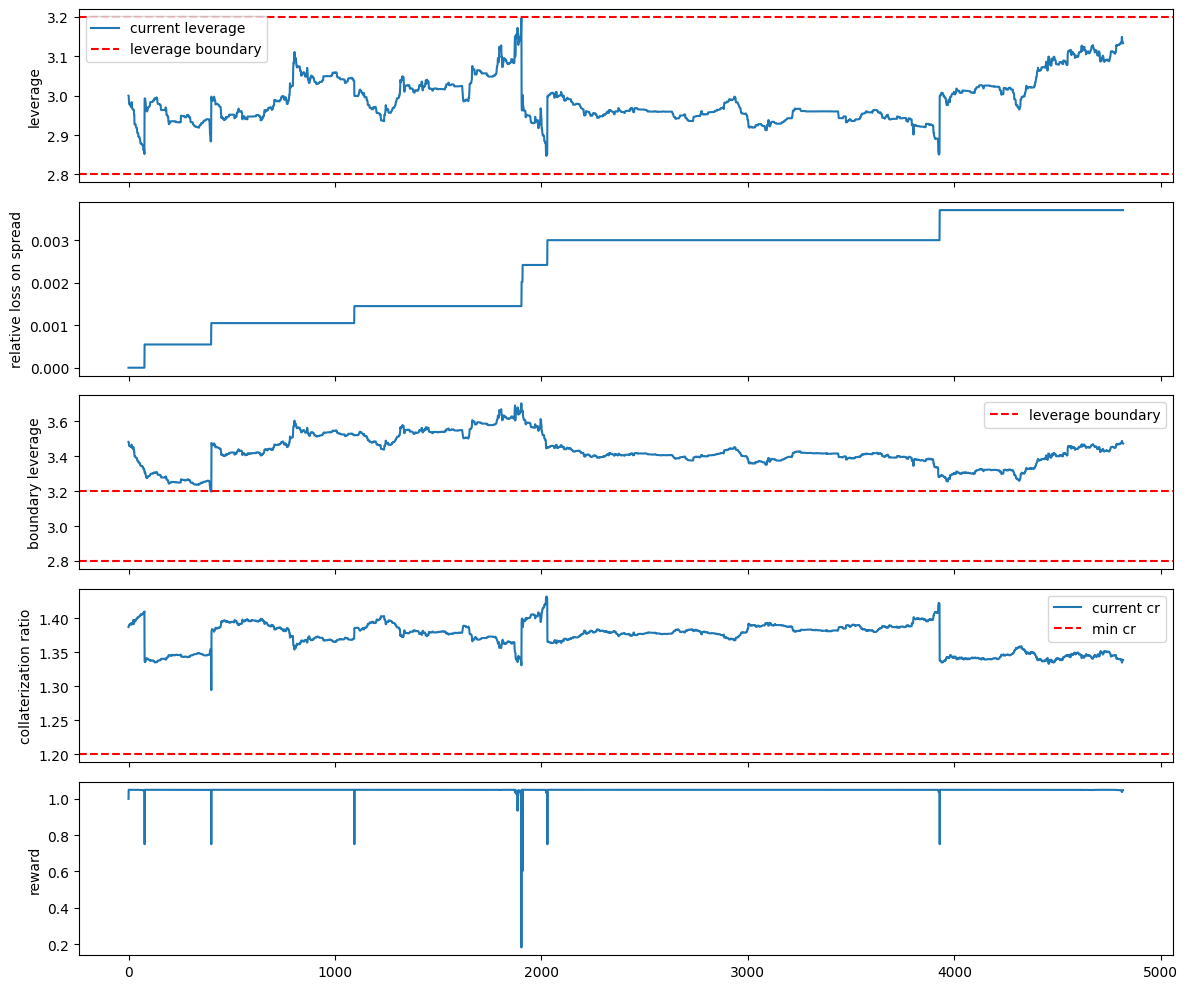

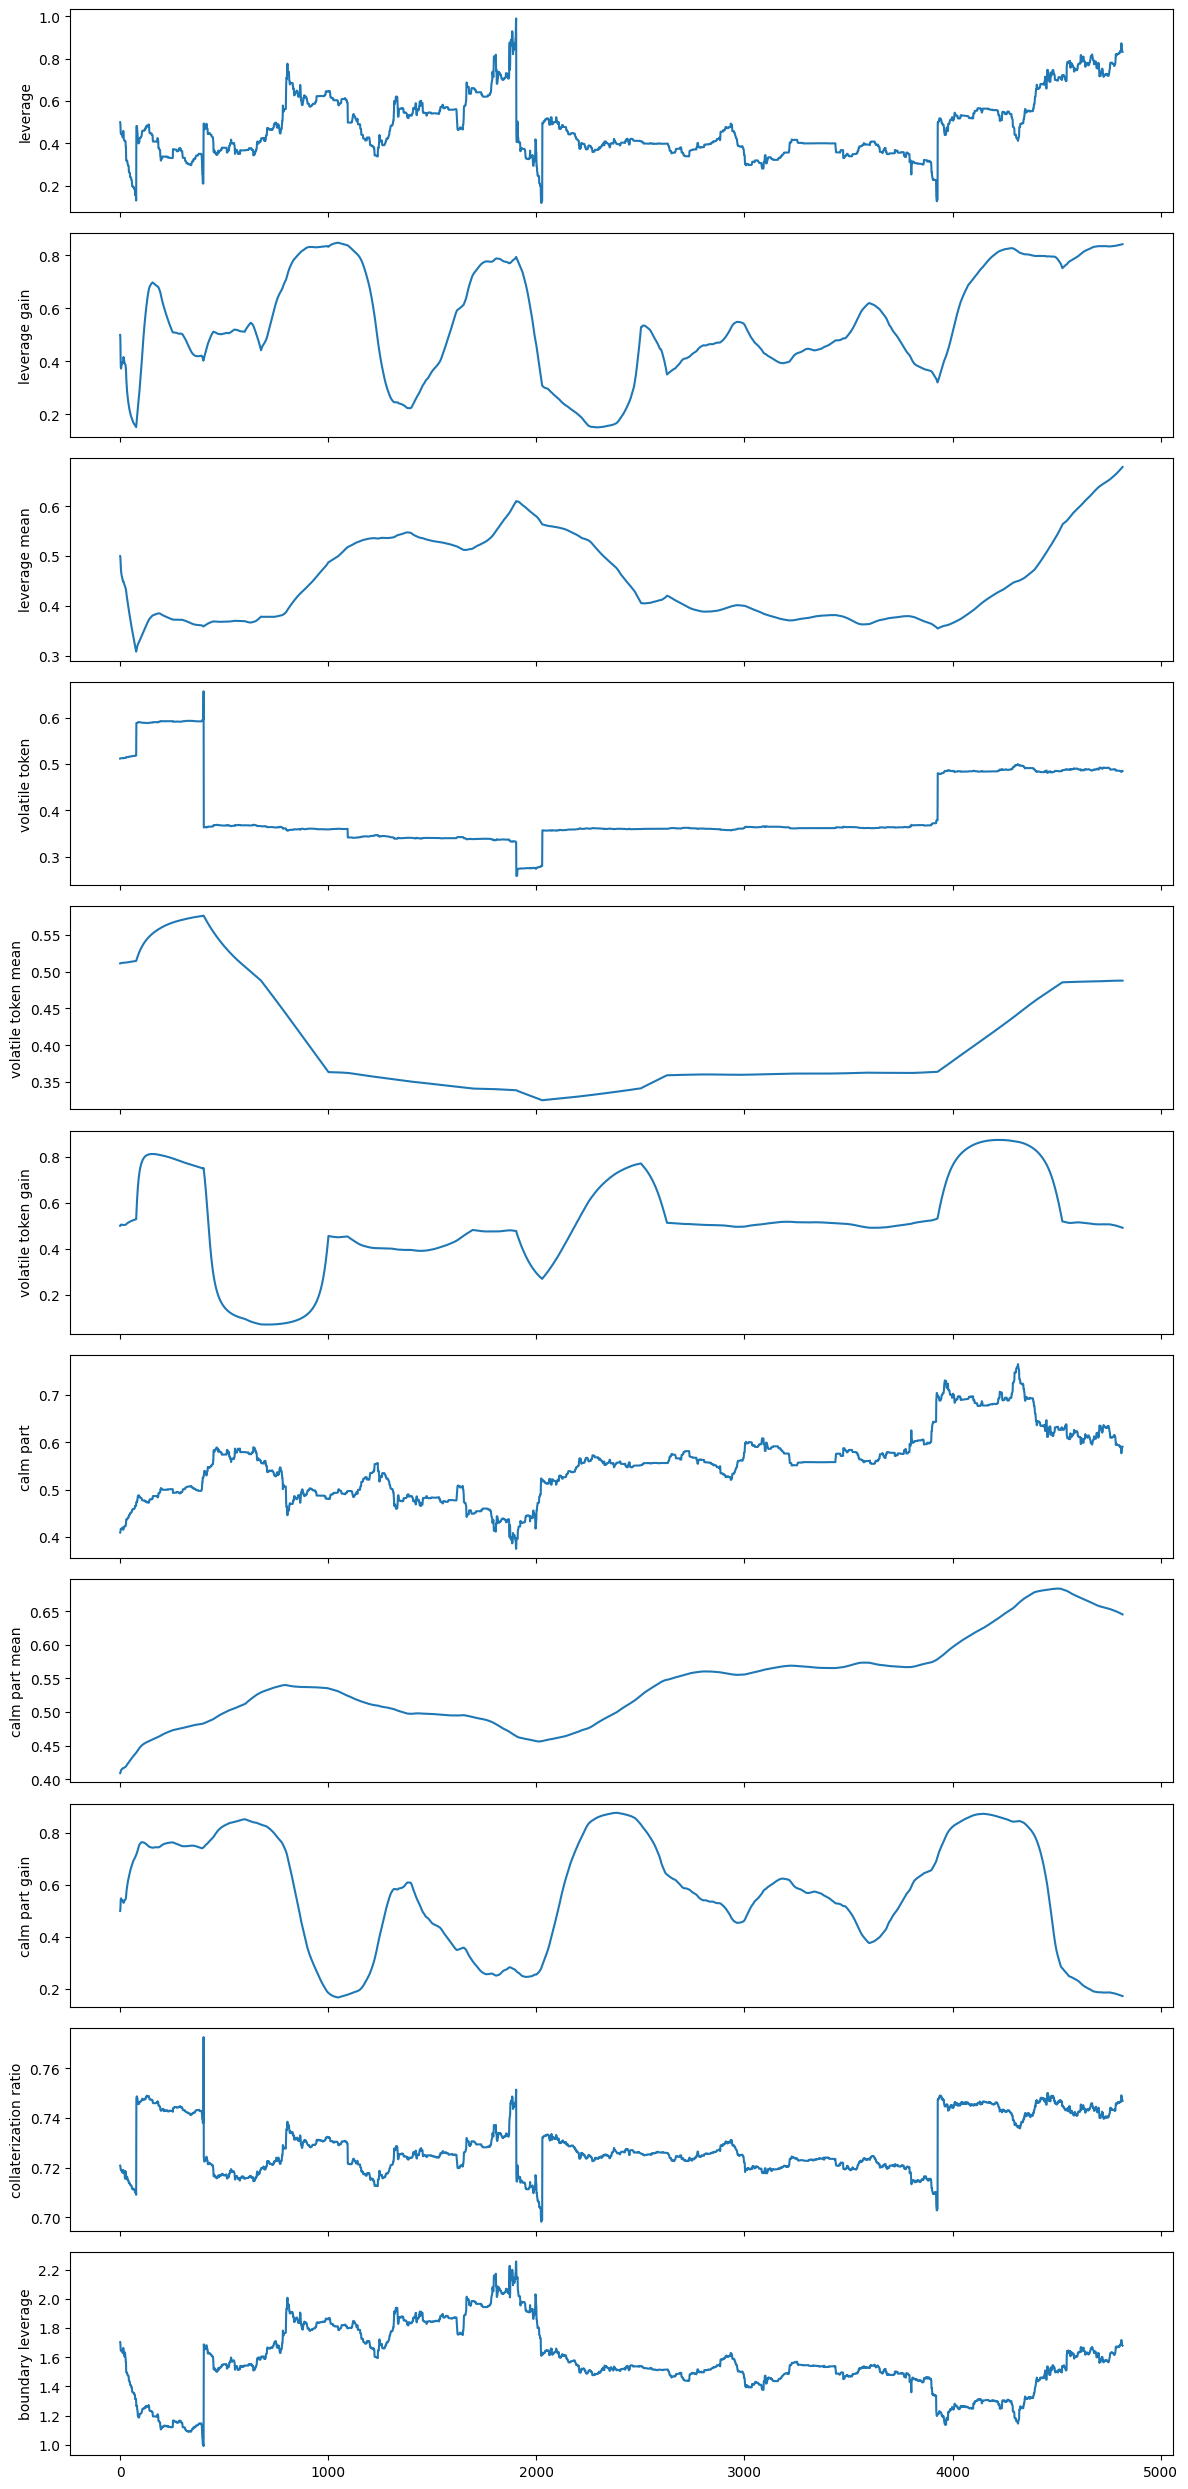

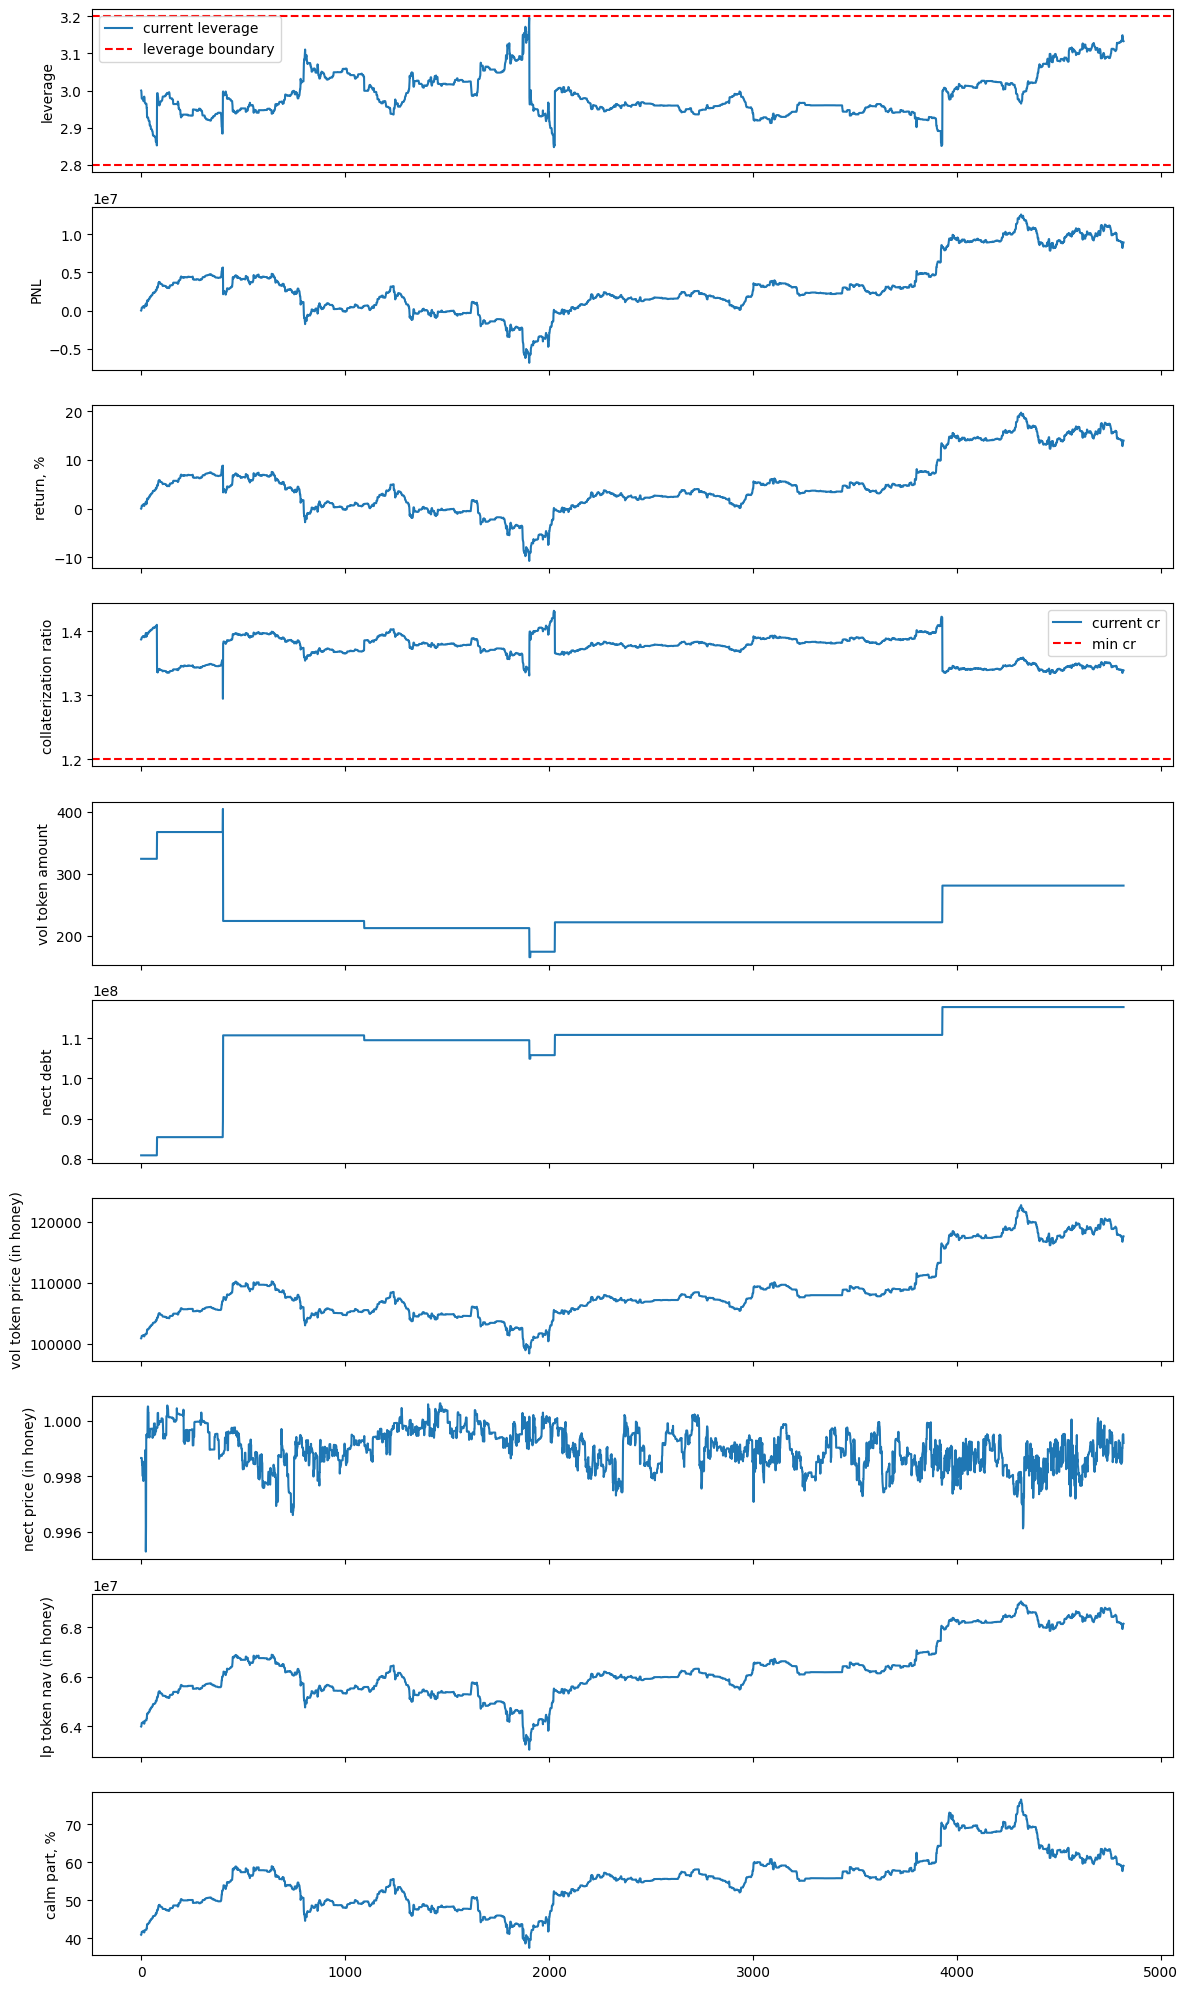

In [7]:
eval_env = agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = True,
    is_reversed = False,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset()
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action, log_prob, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

history = info['episode_history']
history_metrics = info['episode_metrics']
economic_metrics = info['episode_economics']
t_l = info['top leverage']
b_l = info['bottom leverage']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

plot_episode_history_v2(history, t_l, b_l)
plot_metrics_v2(history_metrics)
plot_economic_metrics(economic_metrics, t_l, b_l)

In [7]:
def naiveAgent(obs, min_cr=1.2, eps=1e-9):
    leverage = obs[0]
    cr = 1/obs[1]

    if cr <= min_cr + 0.03:
        return 1
    if leverage >= 0.95 or leverage <= 0.05:
        return 1
    else:
        return 0

env1 = agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = True,
    is_mixed = True,
    is_reversed = True,
    top_leverage = max(TOP_LEVERAGE, BOTTOM_LEVERAGE),
    bottom_leverage = min(TOP_LEVERAGE, BOTTOM_LEVERAGE)
)

env2 = agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = True,
    is_mixed = True,
    is_reversed = True,
    top_leverage = max(TOP_LEVERAGE, BOTTOM_LEVERAGE),
    bottom_leverage = min(TOP_LEVERAGE, BOTTOM_LEVERAGE)
)

def generateEpisode(rng, env1: agentDLVEnvV2, env2: agentDLVEnvV2):
    seed = rng.integers(0, 1e6)

    obs, _ = env1.reset(seed = int(seed))
    done = False
    
    while not done:
        action = naiveAgent(obs)
        obs, reward, terminated, truncated, info = env1.step(action)
        done = terminated or truncated
        if done:
            mech_integral_loss = info['integral loss']
            mech_steps = info['steps']
            mech_quantile = info['quantile']

    obs, _ = env2.reset(seed = int(seed))
    done = False
    hidden = model.init_hidden(batch_size=1, device='cpu')

    ep_obs = []
    ep_actions = []
    ep_logs = []

    while not done:
        action, log_prob, hidden = model.act(obs, hidden)
        obs, reward, terminated, truncated, info = env2.step(action)

        ep_obs.append(obs)
        ep_actions.append(action)
        ep_logs.append(log_prob)

        done = terminated or truncated
        if done:
            ep_integral_loss = info['integral loss']
            ep_steps = info['steps']
            ep_quantile = info['quantile']

    reward = mech_integral_loss - ep_integral_loss

    return {
        "reward": reward,
        "obs": np.array(ep_obs),
        "actions": np.array(ep_actions),
        "log_probs": torch.stack(ep_logs),
        "mechanical_loss": mech_integral_loss,
        "agent_loss": ep_integral_loss,
        "steps": ep_steps,
        "mech_quantile": mech_quantile,
        "agent_quantile": ep_quantile
    }

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1


In [8]:
print(generateEpisode(np.random.default_rng(42), env1, env2))

0.850151975190259
0.850151975190259
{'reward': np.float64(-1.9602438901202106), 'obs': array([[0.34789723, 0.70172286, 0.34925643, ..., 0.55350983, 0.55350983,
        0.5       ],
       [0.34790948, 0.70191336, 0.34880745, ..., 0.55359656, 0.55353874,
        0.5005522 ],
       [0.3566744 , 0.7019031 , 0.35077417, ..., 0.5517823 , 0.55309963,
        0.491351  ],
       ...,
       [0.39314395, 0.6780476 , 0.5388126 , ..., 0.5043371 , 0.5048513 ,
        0.45737782],
       [0.3916565 , 0.67714757, 0.5383768 , ..., 0.5041997 , 0.5048199 ,
        0.4581094 ],
       [0.38841113, 0.6761887 , 0.5379368 , ..., 0.50437117, 0.5047888 ,
        0.45885125]], shape=(4817, 10), dtype=float32), 'actions': array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(4817, 1)), 'log_probs': tensor([[-0.0014],
        [-0.0011],
        [-0.0013],
        ...,
        [-0.0007],
        [-0.0007],
        [-0.0007]], grad_fn=<StackBackward0>), 'mechanical_loss': n

In [9]:
def train_actor_only(model, env1, env2, n_episodes=1000, lr=3e-5, gamma=1.0, device="cpu"):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    rng = np.random.default_rng(42)
    reward_baseline = 0.0
    baseline_alpha = 0.05  # smoothing factor for moving average baseline

    all_rewards = []
    all_losses = []

    for episode in trange(n_episodes, desc="Training"):
        # --- Generate one full episode ---
        ep_data = generateEpisode(rng, env1, env2)

        R = ep_data["reward"]  # mech_loss - agent_loss (higher = better)

        # --- Compute advantage (reward - baseline) ---
        advantage = R - reward_baseline

        # --- Policy gradient loss (REINFORCE) ---
        # Note: minus sign because we *maximize* expected reward
        log_probs = ep_data["log_probs"].to(device)
        reward_t = torch.tensor(advantage, dtype=torch.float32, device=device)

    # --- Compute loss ---
        loss = -(log_probs * reward_t).mean()   # <-- keep log_probs with grad!

        # --- Optimize ---
        optimizer.zero_grad()
        print(log_probs[0].requires_grad)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        # --- Update moving baseline ---
        reward_baseline = (1 - baseline_alpha) * reward_baseline + baseline_alpha * R

        # --- Logging ---
        all_rewards.append(R)
        all_losses.append(loss.item())

        if (episode + 1) % 10 == 0:
            avg_R = np.mean(all_rewards[-10:])
            print(f"Episode {episode+1:04d} | Avg Reward: {avg_R:.4f} | Baseline: {reward_baseline:.4f}")

    return all_rewards, all_losses

In [10]:
train_actor_only(model, env1, env2, 10)

Training:   0%|          | 0/10 [00:00<?, ?it/s]

0.850151975190259
0.850151975190259
True


Training:  10%|█         | 1/10 [00:14<02:11, 14.60s/it]

0.9958625282835314
0.9958625282835314
True


Training:  20%|██        | 2/10 [00:27<01:49, 13.74s/it]

...

Training:  90%|█████████ | 9/10 [02:02<00:13, 13.48s/it]

0.3768630422207244
0.3768630422207244
True


Training: 100%|██████████| 10/10 [02:15<00:00, 13.60s/it]

Episode 0010 | Avg Reward: -4.0718 | Baseline: -1.5173


([np.float64(-6.167489960559816),
  np.float64(-4.3914138420853055),
  np.float64(-10.993318754232249),
  np.float64(-4.701132226245654),
  np.float64(-5.226228280453034),
  np.float64(-3.3467557360193414),
  np.float64(-0.4300193876723508),
  np.float64(-1.2563988727735609),
  np.float64(-1.2872134822454235),
  np.float64(-2.9176120146513718)],
 [-0.09203381836414337,
  -0.08638767153024673,
  -0.22303207218647003,
  -0.05511798337101936,
  -0.04954586923122406,
  -0.0349576398730278,
  0.012456501834094524,
  0.0018236914183944464,
  0.0009713887702673674,
  -0.01320881862193346])